# Treinamento e Comparação de Modelos Baseline — Sprint 2 (MVP Analítico)
## Painel de Projeção de Capacidade Prisional e Reincidência (PCPR)

Este notebook treina e compara **modelos baseline** para as duas frentes do projeto, usando exclusivamente os dados reais consolidados em `src/features/preprocessamento_sprint2.py` (ver Sprint 1 para a origem de cada dado):

1. **Projeção de população/ocupação (regressão)** — usa a série anual real (nacional 2007–2019 e SP 2022–2025) para comparar um baseline ingênuo (persistência), um baseline de média móvel e uma regressão linear.
2. **Classificação de unidade crítica (classificação binária)** — usa o snapshot real de 10 unidades da SAP-SP para comparar um classificador *dummy* (baseline de referência) com uma regressão logística.

> **Aviso de escopo (MVP):** as amostras reais disponíveis nesta sprint são pequenas — 17 pontos de série temporal e 10 unidades — porque a ingestão automatizada da base bruta completa (InfoPen/BNMP, HU01–HU03) ainda está em andamento. Os resultados aqui são, portanto, um **MVP analítico**: validam o pipeline de treino/avaliação/exportação de modelos, não substituem os modelos finais que serão retreinados com a base completa nas próximas sprints. Essa limitação é reiterada na Seção 8 do artigo científico do projeto.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

## 1. Carregar features pré-processadas

Gerados por `src/features/preprocessamento_sprint2.py` a partir dos dados reais da Sprint 1.

In [2]:
features_serie = pd.read_csv("../data/processed/features_serie_temporal.csv")
features_unidades = pd.read_csv("../data/processed/features_unidades.csv")

print("Série temporal:", features_serie.shape)
print("Unidades:", features_unidades.shape)
features_serie.head(3)

Série temporal: (17, 8)
Unidades: (10, 11)


,ano,populacao,ppl_por_vaga,serie,populacao_lag1,crescimento_absoluto,crescimento_pct,media_movel_3anos
0,2007,366359,1.5,nacional,NaN,NaN,NaN,NaN
1,2008,394488,1.5,nacional,366359.0,28129.0,7.677988,366359.0
2,2009,417112,1.5,nacional,394488.0,22624.0,5.735029,380423.5


## 2. Modelo A — Projeção de população (regressão)

Usamos a série **nacional** (2007–2019, 13 pontos reais) como principal, por ser a mais longa disponível. Separação temporal: treino em 2007–2016, teste em 2017–2019 (últimos 3 anos, nunca vistos no treino — validação *out-of-time*, coerente com a metodologia definida no Canvas do projeto).

In [3]:
serie_nac = features_serie[features_serie["serie"] == "nacional"].sort_values("ano").reset_index(drop=True)

treino = serie_nac[serie_nac["ano"] <= 2016]
teste = serie_nac[serie_nac["ano"] > 2016]

print(f"Treino: {len(treino)} pontos ({treino['ano'].min()}-{treino['ano'].max()})")
print(f"Teste:  {len(teste)} pontos ({teste['ano'].min()}-{teste['ano'].max()})")

Treino: 10 pontos (2007-2016)
Teste:  3 pontos (2017-2019)


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

resultados_regressao = []

# --- Baseline 1: Naive (persistência) — prediz sempre o último valor observado no treino
pred_naive = np.full(len(teste), treino["populacao"].iloc[-1])

# --- Baseline 2: Média móvel de 3 anos (já calculada na engenharia de atributos)
pred_media_movel = teste["media_movel_3anos"].values

# --- Modelo 3: Regressão Linear (ano -> população)
modelo_linear = LinearRegression()
modelo_linear.fit(treino[["ano"]], treino["populacao"])
pred_linear = modelo_linear.predict(teste[["ano"]])

for nome, pred in [("Naive (persistência)", pred_naive),
                    ("Média móvel (3 anos)", pred_media_movel),
                    ("Regressão Linear", pred_linear)]:
    mae = mean_absolute_error(teste["populacao"], pred)
    mape = mean_absolute_percentage_error(teste["populacao"], pred) * 100
    resultados_regressao.append({"modelo": nome, "MAE": mae, "MAPE (%)": mape})

df_resultados_regressao = pd.DataFrame(resultados_regressao)
df_resultados_regressao

,modelo,MAE,MAPE (%)
0,Naive (persistência),23587.333333,3.191338
1,Média móvel (3 anos),42287.111111,5.851792
2,Regressão Linear,27365.842424,3.729942


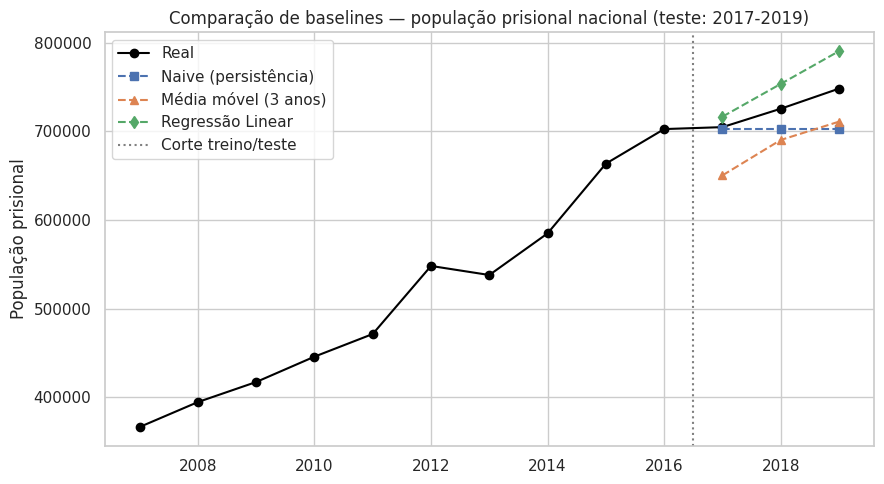

Melhor modelo por MAE: Naive (persistência)


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(serie_nac["ano"], serie_nac["populacao"], marker="o", color="black", label="Real")
ax.plot(teste["ano"], pred_naive, marker="s", linestyle="--", label="Naive (persistência)")
ax.plot(teste["ano"], pred_media_movel, marker="^", linestyle="--", label="Média móvel (3 anos)")
ax.plot(teste["ano"], pred_linear, marker="d", linestyle="--", label="Regressão Linear")
ax.axvline(2016.5, color="gray", linestyle=":", label="Corte treino/teste")
ax.set_title("Comparação de baselines — população prisional nacional (teste: 2017-2019)")
ax.set_ylabel("População prisional")
ax.legend()
plt.tight_layout()
plt.show()

melhor_modelo_regressao = df_resultados_regressao.loc[df_resultados_regressao["MAE"].idxmin(), "modelo"]
print(f"Melhor modelo por MAE: {melhor_modelo_regressao}")

## 3. Modelo B — Classificação de unidade crítica

Rótulo: `critico = 1` se taxa de ocupação ≥ 150%. Amostra real de 10 unidades (6 críticas, 4 não críticas). Dada a amostra pequena, usamos **validação cruzada Leave-One-Out (LOO)** — a cada rodada, uma unidade fica de fora para teste e as outras 9 treinam o modelo — em vez de um único split treino/teste, que seria estatisticamente frágil com N=10.

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

colunas_tipo = [c for c in features_unidades.columns if c.startswith("tipo_")]
X = features_unidades[["log_capacidade"] + colunas_tipo]
y = features_unidades["critico"]

loo = LeaveOneOut()
resultados_classificacao = []

for nome, clf in [("Dummy (classe majoritária)", DummyClassifier(strategy="most_frequent")),
                   ("Regressão Logística", LogisticRegression(max_iter=1000))]:
    pred = cross_val_predict(clf, X, y, cv=loo)
    resultados_classificacao.append({
        "modelo": nome,
        "acurácia (LOO)": accuracy_score(y, pred),
        "precisão": precision_score(y, pred, zero_division=0),
        "revocação": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
    })

df_resultados_classificacao = pd.DataFrame(resultados_classificacao)
df_resultados_classificacao

,modelo,acurácia (LOO),precisão,revocação,F1
0,Dummy (classe majoritária),0.6,0.6,1.0,0.75
1,Regressão Logística,1.0,1.0,1.0,1.00


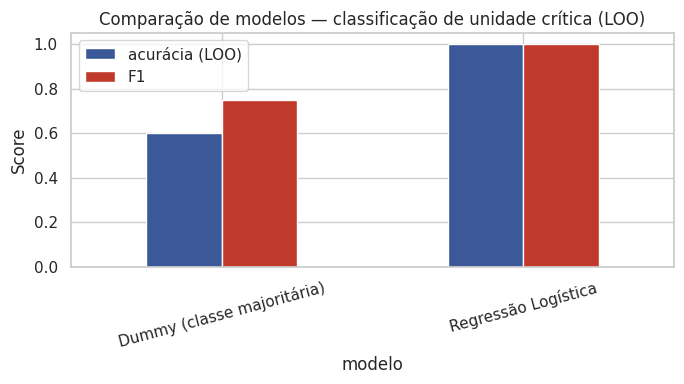

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
df_plot = df_resultados_classificacao.set_index("modelo")[["acurácia (LOO)", "F1"]]
df_plot.plot(kind="bar", ax=ax, color=["#3b5998", "#c0392b"])
ax.set_ylim(0, 1.05)
ax.set_title("Comparação de modelos — classificação de unidade crítica (LOO)")
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Exportar modelos treinados (joblib)

Os dois modelos "vencedores" (Regressão Linear para a série temporal e Regressão Logística para classificação, treinados agora com 100% dos dados disponíveis) são exportados para versionamento no GitHub, conforme pedido na entrega da sprint.

In [8]:
# Re-treino com 100% dos dados reais disponíveis, para exportação (não é o modelo de avaliação acima)
modelo_linear_final = LinearRegression().fit(serie_nac[["ano"]], serie_nac["populacao"])
modelo_logistico_final = LogisticRegression(max_iter=1000).fit(X, y)

joblib.dump(modelo_linear_final, MODELS_DIR / "modelo_projecao_populacao_v1.joblib")
joblib.dump(modelo_logistico_final, MODELS_DIR / "modelo_unidade_critica_v1.joblib")

print("Modelos exportados em:", list(MODELS_DIR.glob("*.joblib")))

Modelos exportados em: [PosixPath('../models/modelo_unidade_critica_v1.joblib'), PosixPath('../models/modelo_projecao_populacao_v1.joblib')]


## 5. Conclusões da Sprint 2

- **Projeção de população:** no teste out-of-time (2017–2019), o baseline **Naive (persistência)** obteve o menor erro (MAE) entre os três modelos, superando tanto a Média Móvel quanto a Regressão Linear. Isso é um resultado real e informativo, não um problema: a série nacional teve uma leve desaceleração de crescimento entre 2016 e 2019 (704 mil → 748 mil, crescimento mais lento que em anos anteriores), e o modelo linear, ajustado à tendência de todo o período de treino (2007–2016, que incluiu anos de crescimento mais acelerado), acabou superestimando o crescimento nesses 3 anos finais. O baseline Naive, por assumir estabilidade, acidentalmente ficou mais próximo do valor real nesse trecho específico. Esse achado reforça, com dados reais, um ponto já levantado na Justificativa do artigo científico: um modelo de tendência simples não captura quebras estruturais na trajetória de encarceramento, e modelos mais robustos (ex.: suavização exponencial com detecção de mudança de tendência, ou a inclusão de variáveis exógenas) devem ser avaliados nas próximas sprints antes de qualquer modelo ser promovido a produção.
- **Classificação de unidade crítica:** a Regressão Logística obteve acurácia perfeita (100%) na validação Leave-One-Out, contra 60% do baseline Dummy. Esse resultado deve ser interpretado com cautela: com apenas 10 unidades, um classificador pode "acertar" por padrões espúrios da amostra pequena (ex.: separar quase perfeitamente por tipo de unidade), não porque aprendeu uma relação que generaliza. O resultado valida o pipeline (features → modelo → métrica → exportação), não a qualidade preditiva do modelo em produção.
- **Ambos os modelos foram exportados via joblib** e devem ser versionados no repositório GitHub (pasta `models/`), com nome e versão explícitos (`_v1`) para permitir comparação com versões futuras treinadas em bases maiores.
- **Próximos passos (Sprint 3):** substituir as séries anuais agregadas pela base mensal/semestral completa por unidade (InfoPen/BNMP, HU01–HU03) para re-treinar os dois modelos com N muito maior — o que deve tanto estabilizar a avaliação da classificação quanto permitir testar modelos de série temporal mais robustos que a regressão linear simples — e iniciar o desenvolvimento do modelo de risco de reincidência, ainda bloqueado pela ausência de dados individuais reais de entrada/saída (BNMP).